# Global Happiness Data Analysis 🌍

This project explores the World Happiness Report dataset to identify key factors that influence happiness across countries.

The analysis focuses on relationships between happiness scores and variables such as GDP, social support, and health, along with regional trends.

## Data Loading & Setup

In [439]:
# %pip install pandas seaborn matplotlib
# maybe had to install again since kernel is virtual
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")

## Data Overview

Understanding the structure of the dataset, including data types and available features.

In [440]:
# Load the dataset
df = pd.read_csv("../data/2019.csv")
df.head()

# Understand the data 
df.info()

# Check column names
df.columns 

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    str    
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 11.1 KB


Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='str')

## Top 10 Happiest Countries

This section identifies the countries with the highest happiness scores.

/var/folders/fv/xdhpr37s31dd4wf8cds6n85w0000gn/T/ipykernel_39283/2237379096.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country or region", y="Score", data=top10, palette="crest")


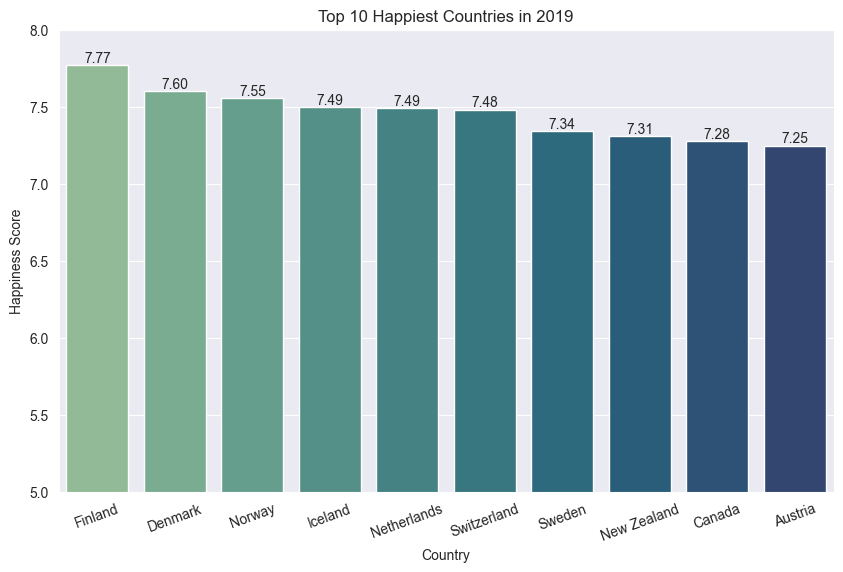

In [441]:
# Top 10 Happiest Countries 

top10 = df.sort_values("Score", ascending=False).head(10)
top10[["Country or region", "Score"]]

# Visualization of the top 10 happiest countries

# Setting the figure size and style
plt.figure(figsize=(10, 6))
sns.set_style(style="darkgrid")
sns.barplot(x="Country or region", y="Score", data=top10, palette="crest")
plt.title("Top 10 Happiest Countries in 2019")

# Customize the plot
plt.ylabel("Happiness Score")
plt.xlabel("Country")
plt.ylim(5, 8)
plt.xticks(rotation=20)

# Add value labels on top of the bars
    # Had to Google how to add value labels on top of bars in seaborn barplot, 
    # and it was a bit tricky since seaborn doesn't have a built-in function for that. 
    # I had to use plt.text() to manually add the labels on top of each bar. 
    # I also had to adjust the y-coordinate of the text to be slightly above the 
    # bar height to make it look better.
for i, v in enumerate(top10["Score"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

# Show the plot
plt.show()   



## Correlation Analysis

To understand relationships between variables, a correlation matrix is calculated for all numeric features.

In [442]:
# Correlation Analysis
import numpy as np  # Ensure numpy is imported for numeric types

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
corr

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Overall rank,1.000000,-0.989096,-0.801947,-0.767465,-0.787411,-0.546606,-0.047993,-0.351959
Score,-0.989096,1.000000,0.793883,0.777058,0.779883,0.566742,0.075824,0.385613
GDP per capita,-0.801947,0.793883,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
Social support,-0.767465,0.777058,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
Healthy life expectancy,-0.787411,0.779883,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
Freedom to make life choices,-0.546606,0.566742,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
Generosity,-0.047993,0.075824,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
Perceptions of corruption,-0.351959,0.385613,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


## Correlation Heatmap

This heatmap visualizes the strength of relationships between variables. Darker colors indicate stronger correlations.

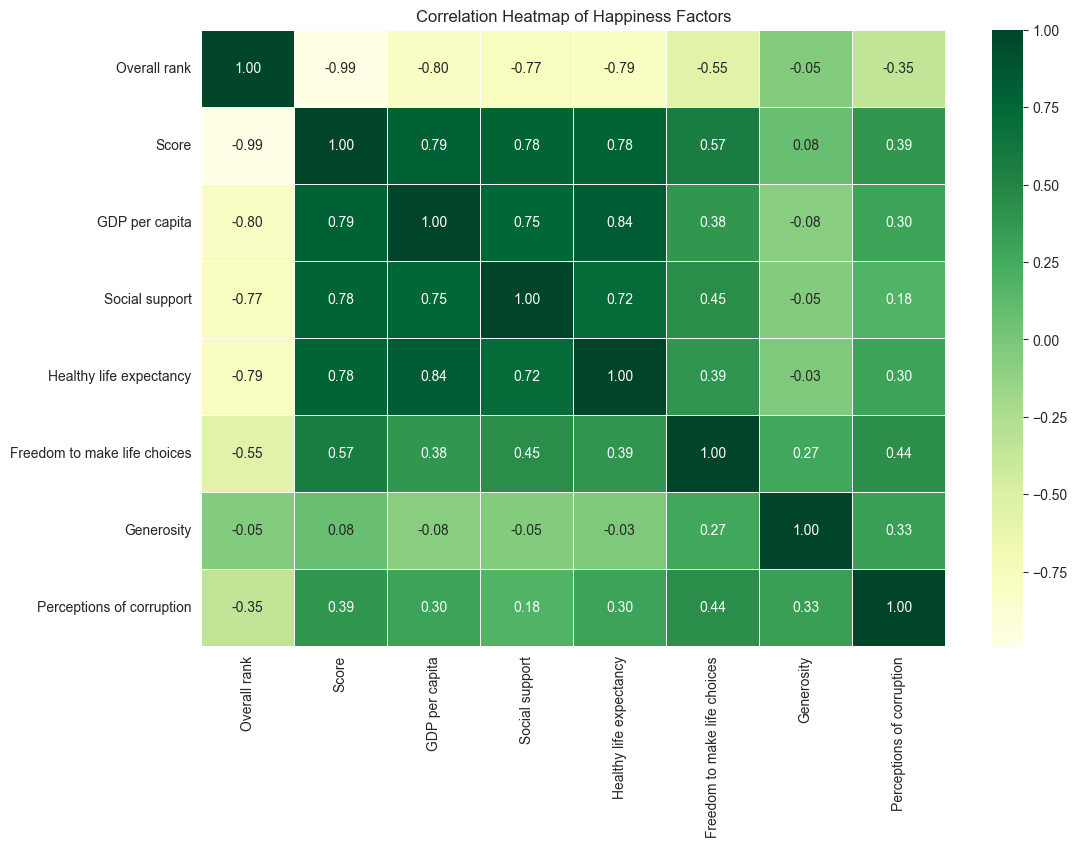

In [443]:
# Heatmap of Correlations
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="YlGn", fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap of Happiness Factors")
plt.show()

## Relationship: GDP vs Happiness

This scatter plot examines the relationship between economic output and happiness levels.

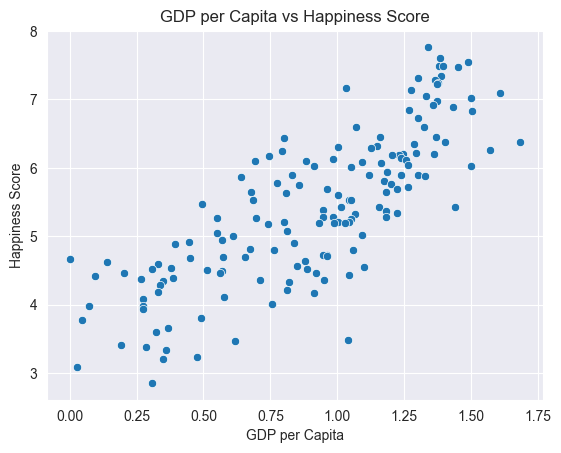

In [444]:
# Relationship: GDP vs Happiness 

sns.scatterplot(data=df, x="GDP per capita", y="Score")
plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.show()

## Relationship: Social Support vs Happiness

This visualization explores how social support relates to happiness levels across countries.

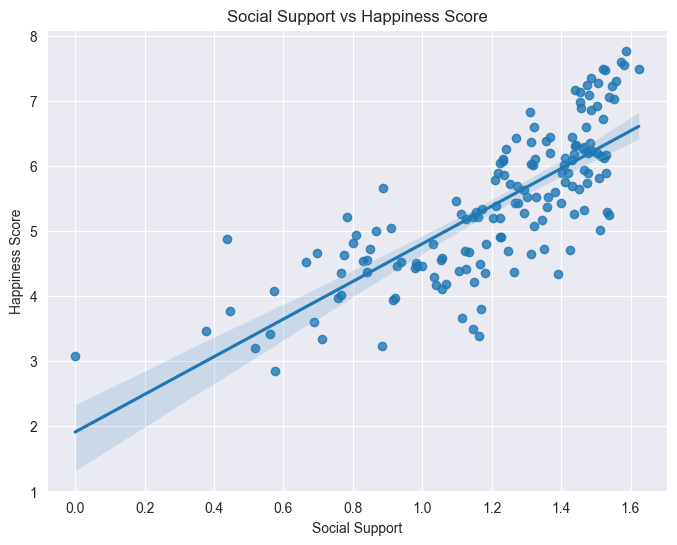

In [445]:
# Relationship: Social Support vs Happiness

plt.figure(figsize=(8,6))
sns.regplot(data=df, x="Social support", y="Score")
plt.title("Social Support vs Happiness Score")
plt.xlabel("Social Support")
plt.ylabel("Happiness Score")

plt.show()


## Key Insights

- Countries with higher GDP per capita generally report higher happiness levels.
- Social support shows a strong positive relationship with happiness, often comparable to or stronger than GDP.
- Health and life expectancy are also strongly associated with higher happiness scores.
- The top happiest countries are largely concentrated in Europe, particularly Nordic regions.

In [446]:
# Wealthy countries tend to be happier, but social support and freedom also play crucial roles.
# Wealthy countries 
df.sort_values("GDP per capita", ascending=False).head(10)


# Happiest countries often have high GDP per capita, but factors like social support and freedom also significantly contribute to happiness.
# Happiest countries 
df.sort_values("Score", ascending=False).head(10)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


## Conclusion

This analysis highlights that while economic factors like GDP play an important role in happiness, social and health-related factors are equally, if not more, significant. Happiness is influenced by a combination of economic stability, social connections, and overall quality of life.